# Formula 1 Scheduling and Routing Optimization
[![f1_scheduling_routing.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/f1/f1_scheduling_routing.ipynb)](https://ampl.com)

Description: A notebook that tackles the Formula 1 Calendar as a routing and a scheduling problem, minimizing total distance between races whilst also assigning a spot in the calendar respecting scheduling constraints using MP

Tags: sports, gurobi, mp, scheduling, f1

Notebook author: Eduardo Salazar <<eduardo@ampl.com>>

Model author: Eduardo Salazar <<eduardo@ampl.com>>



In [1]:
# Install dependencies
%pip install -q amplpy pandas matplotlib seaborn folium

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics


## The Challenge

Formula 1 faces a complex scheduling puzzle every season: arranging 24 races across the globe while minimizing massive logistical costs. The 2026 season includes races from Australia to Abu Dhabi, creating a travel network that spans over 100,000 kilometers if poorly planned.

Currently, F1 calendar planning relies heavily on manual scheduling that considers broadcast timing, venue availability, and regional clustering. However, this approach often results in inefficient routing - teams might race in Asia, then fly to the Americas, then return to Europe, accumulating unnecessary travel distance and costs.

## Why This Matters

The implications extend beyond simple logistics:

- **Economic Impact**: F1 teams spend millions annually on freight and personnel travel
- **Environmental Concerns**: Inefficient routing increases carbon emissions from cargo flights
- **Operational Complexity**: Poor scheduling strains team resources and affects performance
- **Strategic Planning**: Teams need predictable schedules for resource allocation

## The Mathematical Approach

This notebook demonstrates how mathematical programming can optimize complex real-world scheduling problems. Using AMPL's logical constraint capabilities, we model the F1 calendar as an optimization problem with multiple competing objectives and constraints:

- **Objective**: Minimize total travel distance between consecutive race venues
- **Hard Constraints**: Fixed season start/end points, mandatory summer break, venue availability
- **Operational Rules**: Limits on consecutive race weekends, spacing requirements between race clusters

## What You'll See

We'll compare an optimized calendar against the actual 2026 F1 schedule, revealing potential improvements in routing efficiency. The analysis includes:

- Mathematical model formulation using AMPL's MP logical constraints
- Interactive visualizations showing global race routing
- Quantified comparison of travel distances and scheduling patterns
- Calendar views highlighting the optimization's constraint satisfaction

This case study illustrates how operations research techniques can improve real-world logistics, even in highly constrained environments like international motorsport scheduling.

In [3]:
# Import additional libraries
from datetime import datetime, timedelta
from math import atan2, cos, radians, sin, sqrt, degrees
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium import plugins
import seaborn as sns
from IPython.display import display, HTML

print("F1 Calendar Optimization: MP Logical Constraints Demonstration")
print("=" * 70)
print("This notebook showcases AMPL's Mathematical Programming (MP) capabilities")
print("using logical constraints (<==> syntax) for complex scheduling optimization.")
print("\nWe'll compare our optimized solution with the actual 2026 F1 calendar!")

F1 Calendar Optimization: MP Logical Constraints Demonstration
This notebook showcases AMPL's Mathematical Programming (MP) capabilities
using logical constraints (<==> syntax) for complex scheduling optimization.

We'll compare our optimized solution with the actual 2026 F1 calendar!


In [4]:
# ========================================
# 1. F1 CIRCUIT COORDINATES & REAL 2026 CALENDAR
# ========================================

CIRCUIT_COORDINATES = {
    "Australia": (-37.8497, 144.9680),  # Albert Park, Melbourne
    "China": (31.3389, 121.2197),  # Shanghai International Circuit
    "Japan": (34.8431, 136.5411),  # Suzuka Circuit
    "Bahrain": (26.0325, 50.5106),  # Bahrain International Circuit
    "Saudi Arabia": (21.6319, 39.1044),  # Jeddah Corniche Circuit
    "Miami": (25.9581, -80.2389),  # Miami International Autodrome
    "Canada": (45.5000, -73.5228),  # Circuit Gilles Villeneuve, Montreal
    "Monaco": (43.7347, 7.4206),  # Circuit de Monaco
    "Spain Barcelona": (41.5700, 2.2611),  # Circuit de Barcelona-Catalunya
    "Austria": (47.2197, 14.7647),  # Red Bull Ring, Spielberg
    "Great Britain": (52.0786, -1.0169),  # Silverstone Circuit
    "Belgium": (50.4372, 5.9714),  # Circuit de Spa-Francorchamps
    "Hungary": (47.5789, 19.2486),  # Hungaroring, Budapest
    "Netherlands": (52.3888, 4.5409),  # Circuit Zandvoort
    "Italy": (45.6156, 9.2811),  # Autodromo Nazionale Monza
    "Spain Madrid": (40.4168, -3.7038),  # Madrid (IFEMA-Madring circuit)
    "Azerbaijan": (40.3725, 49.8533),  # Baku City Circuit
    "Singapore": (1.2914, 103.8644),  # Marina Bay Street Circuit
    "Austin": (30.1328, -97.6411),  # Circuit of the Americas, Austin
    "Mexico": (19.4042, -99.0907),  # Autódromo Hermanos Rodríguez
    "Brazil": (-23.7036, -46.6997),  # Interlagos, São Paulo
    "Las Vegas": (36.1147, -115.1728),  # Las Vegas Strip Circuit
    "Qatar": (25.4900, 51.4542),  # Lusail International Circuit
    "Abu Dhabi": (24.4672, 54.6031),  # Yas Marina Circuit
}

# Real 2026 F1 Calendar (Official)
REAL_2026_CALENDAR = [
    ("Australia", "2026-03-08"),
    ("China", "2026-03-15"),
    ("Japan", "2026-03-29"),
    ("Bahrain", "2026-04-12"),
    ("Saudi Arabia", "2026-04-19"),
    ("Miami", "2026-05-03"),
    ("Canada", "2026-05-24"),
    ("Monaco", "2026-06-07"),
    ("Spain Barcelona", "2026-06-14"),
    ("Austria", "2026-06-28"),
    ("Great Britain", "2026-07-05"),
    ("Belgium", "2026-07-19"),
    ("Hungary", "2026-07-26"),
    ("Netherlands", "2026-08-23"),
    ("Italy", "2026-09-06"),
    ("Spain Madrid", "2026-09-13"),  # New track!
    ("Azerbaijan", "2026-09-26"),  # Saturday race
    ("Singapore", "2026-10-11"),
    ("Austin", "2026-10-25"),
    ("Mexico", "2026-11-01"),
    ("Brazil", "2026-11-08"),
    ("Las Vegas", "2026-11-21"),  # Saturday night
    ("Qatar", "2026-11-29"),
    ("Abu Dhabi", "2026-12-06"),
]

print(f"{len(CIRCUIT_COORDINATES)} F1 circuits in optimization")
print(f"Real 2026 calendar: {len(REAL_2026_CALENDAR)} races")

24 F1 circuits in optimization
Real 2026 calendar: 24 races


In [5]:
# ========================================
# 2. DISTANCE CALCULATION FUNCTIONS
# ========================================


def calculate_geodesic_distance(coord1, coord2):
    """Calculate great circle distance using Haversine formula"""
    lat1, lon1 = map(radians, coord1)
    lat2, lon2 = map(radians, coord2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    R = 6371  # Earth's radius in km
    return R * c


def create_distance_matrix():
    """Create geodesic distance matrix between all circuits"""
    circuits = list(CIRCUIT_COORDINATES.keys())
    n = len(circuits)
    distance_matrix = np.zeros((n, n))

    print("Computing geodesic distances...")

    for i, circuit1 in enumerate(circuits):
        for j, circuit2 in enumerate(circuits):
            if i != j:
                distance = calculate_geodesic_distance(
                    CIRCUIT_COORDINATES[circuit1], CIRCUIT_COORDINATES[circuit2]
                )
                distance_matrix[i][j] = distance

    return pd.DataFrame(distance_matrix, index=circuits, columns=circuits)


def calculate_total_distance(calendar_sequence, distance_matrix):
    """Calculate total distance for a given race sequence"""
    total = 0
    for i in range(len(calendar_sequence) - 1):
        race1 = calendar_sequence[i]
        race2 = calendar_sequence[i + 1]
        total += distance_matrix.loc[race1, race2]
    return total

# Mathematical Programming Model: F1 Calendar Optimization

## Mathematical Programming Overview

Mathematical Programming (MP) represents optimization problems using mathematical relationships between decision variables, objectives, and constraints. Unlike simple heuristics or manual planning, MP guarantees finding optimal solutions within defined constraint boundaries.

This F1 scheduling problem exemplifies **Mixed-Integer Programming with Logical Constraints** - a sophisticated class of optimization that combines:
- **Binary variables** (yes/no decisions)
- **Integer variables** (discrete choices like week numbers)
- **Logical relationships** (if-then-else rules) through the use of AMPL MP.

## Our Model Architecture

### Decision Variables
```ampl
var x{RACES, POSITIONS} binary;     # Assignment: race r in position p
var w{POSITIONS} integer >= 10, <= 49;  # Week number for each position
var consecutive{p in 1..23} binary;     # Consecutive week indicator
var triple_start{p in 1..22} binary;    # Triple header start indicator
```

### Objective Function
We minimize total great-circle distance between consecutive race venues:
```ampl
minimize TotalDistance:
    sum{p in 1..23} sum{r1 in RACES, r2 in RACES}
        distance[r1, r2] * x[r1, p] * x[r2, p+1];
```

This formulation automatically selects the optimal race sequence by penalizing long-distance transitions.

## Advanced Logical Constraints

The model's sophistication lies in its logical constraint system using AMPL's MP `<==>` (if-and-only-if) syntax:

### Consecutive Race Definition
```ampl
subject to DefineConsecutive{p in 1..23}:
    consecutive[p] <==> (w[p+1] = w[p] + 1);
```
This creates a bidirectional logical relationship: `consecutive[p]` is true if and only if races p and p+1 occur in consecutive weeks.

### Triple Header Management
```ampl
subject to DefineTripleStart{p in 1..22}:
    triple_start[p] <==> (consecutive[p] = 1 and consecutive[p+1] = 1);
```
Defines triple headers (three consecutive race weekends) as a compound logical condition.

### Complex Operational Rules
```ampl
subject to NoMoreThan3InARow{p in 1..21}:
    (consecutive[p] = 1 and consecutive[p+1] = 1) ==> consecutive[p+2] = 0;

subject to BreakAfterTriple{p in 1..21}:
    triple_start[p] = 1 ==> w[p+3] >= w[p+2] + 2;
```

These constraints encode real F1 operational requirements: no more than three consecutive race weekends, with mandatory breaks after intense periods.

## Why This Showcases MP Power

This problem demonstrates several key MP capabilities:

**Complex Constraint Interactions**: Summer break requirements, consecutive race limits, and distance optimization create competing objectives that simple heuristics cannot balance effectively.

**Logical Constraint Modeling**: The `<==>` syntax allows natural expression of "if-and-only-if" relationships that would require complex reformulations in basic linear programming.

**Real-World Validation**: Comparing against the actual 2026 F1 calendar provides concrete evidence of optimization benefits.

**Scalability**: The model structure could easily extend to additional constraints (weather patterns, broadcast preferences, venue costs) without fundamental reformulation.

## Model Complexity

The complete formulation includes:
- **600+ binary variables** (24 races × 25 positions + consecutive indicators)
- **24 integer variables** (week assignments)  
- **50+ constraints** (logical, operational, and assignment rules)
- **Nonlinear relationships** (a quadratic objective)


## Technical Innovation

The model demonstrates several advanced MP techniques:
- **Logical constraints** for complex rule modeling
- **Geodesic distance calculations** for realistic objective functions  
- **Temporal constraint networks** for scheduling optimization

This combination showcases MP's ability to handle real-world complexity while maintaining mathematical rigor and solution optimality.

---

*The following cells implement this mathematical model using AMPL and demonstrate its application to the 2026 F1 calendar optimization.*

In [6]:
%%writefile f1.mod
# ========================================
# F1 CALENDAR OPTIMIZATION MODEL
# ========================================

set RACES;
set POSITIONS = 1..24;
param distance{RACES, RACES} >= 0;

# ========================================
# VARIABLES
# ========================================
# Assignment variables
var x{RACES, POSITIONS} binary;

# Week assignment
var w{POSITIONS} integer >= 10, <= 49;

# Binary variable: 1 if race p+1 is in the week immediately after race p
var consecutive{p in 1..23} binary;

# Binary variable: 1 if this starts a triple header (3 consecutive races)
var triple_start{p in 1..22} binary;

# ========================================
# OBJECTIVE
# ========================================
minimize TotalDistance:
    sum{p in 1..23} sum{r1 in RACES, r2 in RACES}
        distance[r1, r2] * x[r1, p] * x[r2, p+1];

# ========================================
# CORE CONSTRAINTS
# ========================================
# Assignment constraints
subject to OnePositionPerRace{r in RACES}:
    sum{p in POSITIONS} x[r, p] = 1;

subject to OneRacePerPosition{p in POSITIONS}:
    sum{r in RACES} x[r, p] = 1;

# Fixed endpoints
subject to StartAustralia:
    x['Australia', 1] = 1;

subject to EndAbuDhabi:
    x['Abu Dhabi', 24] = 1;

# Week ordering (at least 1 week between races)
subject to StrictWeekOrder{p in 1..23}:
    w[p] + 1 <= w[p+1];

# Start and end weeks
subject to FirstWeek:
    w[1] = 10;

subject to LastWeek:
    w[24] = 49;

# ========================================
# SUMMER BREAK CONSTRAINTS
# ========================================
# No races in weeks 31-33
subject to SummerBreak{p in POSITIONS}:
    w[p] <= 30 or w[p] >= 34;

# Ensure break happens around middle
subject to BeforeBreak:
    w[12] <= 30;

subject to AfterBreak:
    w[13] >= 34;

# ========================================
# DEFINE CONSECUTIVE RACES
# ========================================
# Define when races are in consecutive weeks
subject to DefineConsecutive{p in 1..23}:
    consecutive[p] <==> (w[p+1] = w[p] + 1);

subject to NonConsecutiveGap{p in 1..23}:
    (not consecutive[p]) ==> (w[p+1] >= w[p] + 2);

# Define triple header starts
# A triple header starts at position p if p, p+1, p+2 are all consecutive
subject to DefineTripleStart{p in 1..22}:
    triple_start[p] <==> (consecutive[p] = 1 and consecutive[p+1] = 1);

# ========================================
# MAIN CONSECUTIVE RACE CONSTRAINTS
# ========================================

# 1. NO MORE THAN 3 RACES IN A ROW - ABSOLUTE MAXIMUM
# This means if we have 3 consecutive races, the 4th CANNOT be consecutive
subject to NoMoreThan3InARow{p in 1..21}:
    (consecutive[p] = 1 and consecutive[p+1] = 1) ==> consecutive[p+2] = 0;

# Alternative formulation: If three races are consecutive, break the chain
subject to BreakAfter3Consecutive{p in 1..21}:
    consecutive[p] + consecutive[p+1] + consecutive[p+2] <= 2;

# 2. MAXIMUM 2 TRIPLE HEADERS IN THE ENTIRE CALENDAR
subject to MaxTwoTripleHeaders:
    sum{p in 1..22} triple_start[p] <= 2;

# 3. AFTER A DOUBLE HEADER (exactly 2 consecutive), NEED A BREAK
# If p and p+1 are consecutive but p+2 is not consecutive, then need gap after p+1
subject to BreakAfterDouble{p in 1..22}:
    (consecutive[p] = 1 and consecutive[p+1] = 0) ==> w[p+2] >= w[p+1] + 2;

# 4. AFTER A TRIPLE HEADER (exactly 3 consecutive), NEED A BREAK
# If p starts a triple header, then race p+3 must have a gap
subject to BreakAfterTriple{p in 1..21}:
    triple_start[p] = 1 ==> w[p+3] >= w[p+2] + 2;

# ========================================
# ADDITIONAL SAFETY CONSTRAINTS
# ========================================

# Explicit prevention of 4+ consecutive races
subject to Prevent4Consecutive{p in 1..21}:
    not (w[p+1] = w[p] + 1 and w[p+2] = w[p+1] + 1 and w[p+3] = w[p+2] + 1);

# Ensure gaps between clusters
subject to GapBetweenClusters{p in 2..22}:
    (consecutive[p-1] = 1 and consecutive[p] = 0 and consecutive[p+1] = 1) ==>
    w[p+1] >= w[p] + 2;

Writing f1.mod


In [7]:
# ========================================
# 4. SOLUTION PROCESSING
# ========================================


def solve_mp_model(distance_matrix):
    """Solve the MP model and extract solution"""

    print("\n" + "=" * 50)
    print("SOLVING WITH AMPL MP LOGICAL CONSTRAINTS")
    print("=" * 50)

    # Use the global AMPL instance created in setup
    global ampl
    ampl.reset()  # Clear any previous model
    ampl.read("f1.mod")

    races = list(distance_matrix.index)
    ampl.set["RACES"] = races
    ampl.param["distance"] = distance_matrix

    # Configure Gurobi (already installed via ampl_notebook)
    ampl.option["solver"] = "gurobi"
    ampl.option["gurobi_options"] = "timelimit=600 outlev=1"

    print("Solving with MP logical constraints...")
    print("   Model features:")
    print(f"   • {len(races)} races, {24} positions")
    print(f"   • {len(races)*24 + 24 + 23 + 22} decision variables")
    print("   • Logical constraints with <==> operators")
    print("   • Complex clustering and timing constraints")

    ampl.solve()

    solve_result = ampl.get_value("solve_result")
    print(f"Solver status: {solve_result}")

    if "infeasible" in solve_result.lower():
        print("Model is infeasible!")
        return None, None

    # Extract solution
    x_vals = ampl.var["x"]
    w_vals = ampl.var["w"]

    optimized_calendar = []
    optimized_weeks = []
    for p in range(1, 25):
        for race in races:
            if x_vals[race, p].value() > 0.5:
                week = int(w_vals[p].value())
                optimized_calendar.append(race)
                optimized_weeks.append(week)
                break

    total_distance = ampl.get_objective("TotalDistance").value()

    print(f"Optimized total distance: {total_distance:,.0f} km")

    return optimized_calendar, optimized_weeks, total_distance

In [8]:
# ========================================
# 5. VISUALIZATION FUNCTIONS - PART 1: MAP HELPERS
# ========================================


def calculate_great_circle_points(coord1, coord2, num_points=100):
    """
    Calculate intermediate points along a great circle path.
    Properly handles crossing the International Date Line.
    """
    lat1, lon1 = map(radians, coord1)
    lat2, lon2 = map(radians, coord2)

    # Calculate the great circle distance
    dlon = lon2 - lon1

    # Adjust for crossing the date line (shortest path)
    if abs(dlon) > np.pi:
        if dlon > 0:
            dlon = -(2 * np.pi - dlon)
        else:
            dlon = 2 * np.pi + dlon

    points = []
    for i in range(num_points + 1):
        fraction = i / num_points

        # Calculate intermediate point using spherical interpolation
        a = sin((1 - fraction) * abs(dlon)) / sin(abs(dlon))
        b = sin(fraction * abs(dlon)) / sin(abs(dlon))

        # Handle the special case where points are very close
        if abs(dlon) < 0.001:
            # Linear interpolation for very close points
            lat = lat1 * (1 - fraction) + lat2 * fraction
            lon = lon1 * (1 - fraction) + lon2 * fraction
        else:
            # Spherical interpolation
            x = a * cos(lat1) * cos(lon1) + b * cos(lat2) * cos(
                lon2 if dlon >= 0 else lon2 - 2 * np.pi
            )
            y = a * cos(lat1) * sin(lon1) + b * cos(lat2) * sin(
                lon2 if dlon >= 0 else lon2 - 2 * np.pi
            )
            z = a * sin(lat1) + b * sin(lat2)

            lat = atan2(z, sqrt(x**2 + y**2))
            lon = atan2(y, x)

        points.append([degrees(lat), degrees(lon)])

    return points


def create_improved_folium_map(calendar, circuit_coords, title, color="blue"):
    """
    Create an improved Folium map that handles trans-oceanic routes correctly.
    """
    # Create base map
    m = folium.Map(location=[20, 0], zoom_start=2, max_bounds=True)

    # Add all circuit markers
    for i, race in enumerate(calendar):
        lat, lon = circuit_coords[race]

        # Add circuit marker
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            popup=f"<b>{i+1}. {race}</b>",
            tooltip=f"{i+1}. {race}",
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            weight=2,
        ).add_to(m)

        # Add race number label
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f"""<div style="
                    font-size: 12px;
                    color: white;
                    font-weight: bold;
                    background-color: {color};
                    border-radius: 50%;
                    width: 20px;
                    height: 20px;
                    text-align: center;
                    line-height: 20px;
                    ">{i+1}</div>""",
                icon_size=(20, 20),
                icon_anchor=(10, 10),
            ),
        ).add_to(m)

    # Add route lines with proper great circle handling
    for i in range(len(calendar) - 1):
        race1 = calendar[i]
        race2 = calendar[i + 1]
        coord1 = circuit_coords[race1]
        coord2 = circuit_coords[race2]

        # Check if route crosses the International Date Line
        lon1, lon2 = coord1[1], coord2[1]

        # If longitude difference is > 180, it's a trans-Pacific route
        if abs(lon2 - lon1) > 180:
            # Split the route at the date line
            if lon1 > 0 and lon2 < 0:  # Westward crossing (e.g., Asia to Americas)
                # Create two segments
                mid_lat = (coord1[0] + coord2[0]) / 2

                # Segment 1: From origin to date line (180°)
                folium.PolyLine(
                    [[coord1[0], coord1[1]], [mid_lat, 180]],
                    color=color,
                    weight=2,
                    opacity=0.6,
                    smooth_factor=1,
                ).add_to(m)

                # Segment 2: From date line (-180°) to destination
                folium.PolyLine(
                    [[mid_lat, -180], [coord2[0], coord2[1]]],
                    color=color,
                    weight=2,
                    opacity=0.6,
                    smooth_factor=1,
                ).add_to(m)
            elif lon1 < 0 and lon2 > 0:  # Eastward crossing (e.g., Americas to Asia)
                # Create two segments
                mid_lat = (coord1[0] + coord2[0]) / 2

                # Segment 1: From origin to date line (-180°)
                folium.PolyLine(
                    [[coord1[0], coord1[1]], [mid_lat, -180]],
                    color=color,
                    weight=2,
                    opacity=0.6,
                    smooth_factor=1,
                ).add_to(m)

                # Segment 2: From date line (180°) to destination
                folium.PolyLine(
                    [[mid_lat, 180], [coord2[0], coord2[1]]],
                    color=color,
                    weight=2,
                    opacity=0.6,
                    smooth_factor=1,
                ).add_to(m)
        else:
            # Normal route that doesn't cross date line
            # Use great circle points for curved path
            points = calculate_great_circle_points(coord1, coord2, num_points=50)

            folium.PolyLine(
                points, color=color, weight=2, opacity=0.6, smooth_factor=1
            ).add_to(m)

    # Add title
    title_html = f"""
    <h3 align="center" style="font-size:18px; margin: 10px;"><b>{title}</b></h3>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    return m

In [9]:
# ========================================
# 5. VISUALIZATION FUNCTIONS - PART 2: MAP CREATION
# ========================================


def create_static_world_map(calendar, circuit_coords, title, color="green", ax=None):
    """
    Create a static matplotlib visualization with proper great circle routes.
    This avoids all projection issues by using matplotlib's built-in capabilities.
    """
    if ax is None:
        fig = plt.figure(figsize=(20, 10))
        ax = plt.subplot(
            111, projection="mollweide"
        )  # Mollweide projection shows the whole world nicely

    # Convert coordinates for Mollweide projection (requires radians)
    def transform_coords(lat, lon):
        # Mollweide expects longitude in [-pi, pi] and latitude in [-pi/2, pi/2]
        return radians(lon), radians(lat)

    # Draw base map features
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#e6f2ff")  # Light blue for oceans

    # Plot all circuits
    for i, race in enumerate(calendar):
        lat, lon = circuit_coords[race]
        x, y = transform_coords(lat, lon)

        # Plot circuit point
        ax.plot(
            x,
            y,
            "o",
            color=color,
            markersize=10,
            markeredgecolor="white",
            markeredgewidth=1,
            zorder=5,
        )

        # Add text label (offset slightly to avoid overlap)
        ax.text(
            x,
            y + 0.05,
            str(i + 1),
            fontsize=8,
            ha="center",
            va="bottom",
            color="darkblue",
            fontweight="bold",
            zorder=6,
        )

    # Draw routes with great circle paths
    for i in range(len(calendar) - 1):
        race1 = calendar[i]
        race2 = calendar[i + 1]
        lat1, lon1 = circuit_coords[race1]
        lat2, lon2 = circuit_coords[race2]

        # Check if we need to handle date line crossing
        if abs(lon2 - lon1) > 180:
            # Trans-Pacific or trans-Atlantic route
            if lon1 > 0 and lon2 < 0:  # Westward
                # Adjust longitude for shortest path
                lon2_adjusted = lon2 + 360
            elif lon1 < 0 and lon2 > 0:  # Eastward
                # Adjust longitude for shortest path
                lon1_adjusted = lon1 + 360
                lon1, lon2 = lon2, lon1_adjusted
                lat1, lat2 = lat2, lat1

            # Create interpolated points for smooth curve
            num_points = 100
            lons = np.linspace(
                lon1,
                (
                    lon2
                    if abs(lon2 - lon1) <= 180
                    else lon2 + 360 if lon2 < lon1 else lon2 - 360
                ),
                num_points,
            )

            # Normalize longitudes to [-180, 180]
            lons = ((lons + 180) % 360) - 180

            # Simple latitude interpolation (good enough for visualization)
            lats = np.linspace(lat1, lat2, num_points)

            # Transform and plot
            xs, ys = [], []
            for lat, lon in zip(lats, lons):
                x, y = transform_coords(lat, lon)
                xs.append(x)
                ys.append(y)

            # Handle discontinuity at date line
            # Split the path where there's a large jump in x coordinates
            segments = []
            current_segment_x = [xs[0]]
            current_segment_y = [ys[0]]

            for j in range(1, len(xs)):
                if (
                    abs(xs[j] - xs[j - 1]) > np.pi
                ):  # Large jump indicates date line crossing
                    # End current segment
                    segments.append((current_segment_x, current_segment_y))
                    # Start new segment
                    current_segment_x = [xs[j]]
                    current_segment_y = [ys[j]]
                else:
                    current_segment_x.append(xs[j])
                    current_segment_y.append(ys[j])

            # Add final segment
            segments.append((current_segment_x, current_segment_y))

            # Plot all segments
            for seg_x, seg_y in segments:
                ax.plot(
                    seg_x, seg_y, "-", color=color, linewidth=1.5, alpha=0.6, zorder=3
                )
        else:
            # Normal route
            x1, y1 = transform_coords(lat1, lon1)
            x2, y2 = transform_coords(lat2, lon2)

            # Create curved path
            num_points = 50
            lons = np.linspace(lon1, lon2, num_points)
            lats = np.linspace(lat1, lat2, num_points)

            xs = [radians(lon) for lon in lons]
            ys = [radians(lat) for lat in lats]

            ax.plot(xs, ys, "-", color=color, linewidth=1.5, alpha=0.6, zorder=3)

    # Labels and title
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

    # Create custom x-axis labels
    ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    ax.set_xticklabels(["180°W", "90°W", "0°", "90°E", "180°E"])
    ax.set_yticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
    ax.set_yticklabels(["90°S", "45°S", "0°", "45°N", "90°N"])

    return ax


def create_dual_map_comparison(
    optimized_calendar, real_calendar, circuit_coords, optimized_distance, real_distance
):
    """
    Create side-by-side static maps for better comparison.
    This completely avoids the trans-Pacific routing issues.
    """
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(24, 10), subplot_kw={"projection": "mollweide"}
    )

    # Optimized route
    create_static_world_map(
        optimized_calendar,
        circuit_coords,
        f"MP Optimized Route\nTotal: {optimized_distance:,.0f} km",
        color="green",
        ax=ax1,
    )

    # Real 2026 route
    real_races = [race for race, date in real_calendar]
    create_static_world_map(
        real_races,
        circuit_coords,
        f"Real 2026 F1 Calendar\nTotal: {real_distance:,.0f} km",
        color="red",
        ax=ax2,
    )

    # Overall title
    fig.suptitle(
        "F1 Calendar Route Comparison - 2026 Season",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    # Add savings text
    savings = real_distance - optimized_distance
    savings_pct = (savings / real_distance) * 100
    fig.text(
        0.5,
        0.02,
        f"Optimization Savings: {savings:,.0f} km ({savings_pct:.1f}%)",
        ha="center",
        fontsize=14,
        fontweight="bold",
        color="darkgreen",
    )

    plt.tight_layout()
    return fig

In [10]:
# ========================================
# 5. VISUALIZATION FUNCTIONS - PART 3: CALENDAR VIEWS
# ========================================


def create_calendar_view_fixed(
    optimized_calendar,
    optimized_weeks,
    real_calendar,
    optimized_distance,
    real_distance,
):
    """Create a calendar-style visualization showing weekly schedule using ACTUAL optimized weeks"""

    print(f"\nWEEKLY CALENDAR COMPARISON")
    print("=" * 80)

    # Real 2026 calendar weeks (extracted from dates)
    real_weeks = []
    for race, date_str in real_calendar:
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        week_num = date_obj.isocalendar()[1]
        real_weeks.append(week_num)

    print(f"OPTIMIZED SCHEDULE (Total: {optimized_distance:,.0f} km)")
    print("-" * 80)

    # Create comparison table using ACTUAL optimized weeks
    print("Week | Optimized Route      | Real 2026 Calendar   | Notes")
    print("-" * 80)

    all_weeks = set(optimized_weeks + real_weeks)

    for week in sorted(all_weeks):
        if 31 <= week <= 33:
            print(
                f"{week:2d}   | {'SUMMER BREAK':^20} | {'SUMMER BREAK':^20} | 🏖️  Mandatory break"
            )
            continue

        opt_race = ""
        real_race = ""

        # Find optimized race for this week
        if week in optimized_weeks:
            idx = optimized_weeks.index(week)
            opt_race = optimized_calendar[idx]

        # Find real race for this week
        if week in real_weeks:
            idx = real_weeks.index(week)
            real_race = real_calendar[idx][0]

        # Notes
        note = ""
        if opt_race and real_race:
            if opt_race == real_race:
                note = "Same"
            else:
                note = "Different"
        elif opt_race:
            note = "Opt only"
        elif real_race:
            note = "Real only"

        print(f"{week:2d}   | {opt_race:^20} | {real_race:^20} | {note}")

    print("-" * 80)
    print(f"TOTAL DISTANCES:")
    print(f"   Optimized: {optimized_distance:>10,.0f} km")
    print(f"   Real 2026: {real_distance:>10,.0f} km")
    print(
        f"   Savings:   {real_distance - optimized_distance:>10,.0f} km ({((real_distance - optimized_distance)/real_distance*100):>5.1f}%)"
    )

    return optimized_weeks, real_weeks


def create_gantt_chart_fixed(
    optimized_calendar, real_calendar, optimized_weeks, real_weeks
):
    """Create a Gantt chart visualization using ACTUAL optimized weeks"""

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Optimized schedule - use ACTUAL optimized weeks
    ax1.barh(
        range(len(optimized_calendar)),
        [1] * len(optimized_calendar),
        left=optimized_weeks,
        color="green",
        alpha=0.7,
        height=0.6,
    )

    ax1.set_yticks(range(len(optimized_calendar)))
    ax1.set_yticklabels(
        [f"{i+1}. {race}" for i, race in enumerate(optimized_calendar)], fontsize=8
    )
    ax1.set_xlabel("Calendar Week")
    ax1.set_title(
        "MP Optimized F1 Calendar (Actual Optimized Weeks)",
        fontsize=14,
        fontweight="bold",
    )
    ax1.set_xlim(8, 52)
    ax1.grid(axis="x", alpha=0.3)

    # Add summer break highlight
    ax1.axvspan(31, 33, alpha=0.3, color="red", label="Summer Break")
    ax1.legend()

    # Real 2026 schedule
    real_races = [race for race, date in real_calendar]
    ax2.barh(
        range(len(real_races)),
        [1] * len(real_races),
        left=real_weeks,
        color="red",
        alpha=0.7,
        height=0.6,
    )

    ax2.set_yticks(range(len(real_races)))
    ax2.set_yticklabels(
        [f"{i+1}. {race}" for i, race in enumerate(real_races)], fontsize=8
    )
    ax2.set_xlabel("Calendar Week")
    ax2.set_title("Real 2026 F1 Calendar", fontsize=14, fontweight="bold")
    ax2.set_xlim(8, 52)
    ax2.grid(axis="x", alpha=0.3)

    # Add summer break highlight
    ax2.axvspan(31, 33, alpha=0.3, color="red", label="Summer Break")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return fig


def analyze_calendars_fixed(
    optimized_calendar, optimized_weeks, real_calendar, distance_matrix
):
    """Detailed analysis using optimized weeks"""

    print(f"\nDETAILED CALENDAR ANALYSIS WITH ACTUAL WEEKS")
    print("=" * 70)

    # Real 2026 calendar weeks
    real_weeks = []
    for race, date_str in real_calendar:
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        week_num = date_obj.isocalendar()[1]
        real_weeks.append(week_num)

    # Create comparison DataFrame
    comparison_data = []

    for i in range(24):
        opt_race = optimized_calendar[i]
        opt_week = optimized_weeks[i]
        real_race = real_calendar[i][0]
        real_week = real_weeks[i]

        # Calculate distance from previous race
        if i > 0:
            opt_prev_dist = distance_matrix.loc[optimized_calendar[i - 1], opt_race]
            real_prev_dist = distance_matrix.loc[real_calendar[i - 1][0], real_race]
        else:
            opt_prev_dist = 0
            real_prev_dist = 0

        comparison_data.append(
            {
                "Position": i + 1,
                "Optimized_Race": opt_race,
                "Optimized_Week": opt_week,
                "Real_Race": real_race,
                "Real_Week": real_week,
                "Opt_Distance": opt_prev_dist,
                "Real_Distance": real_prev_dist,
                "Distance_Difference": real_prev_dist - opt_prev_dist,
                "Week_Difference": real_week - opt_week,
            }
        )

    df = pd.DataFrame(comparison_data)

    print("Pos | Optimized (Week)     | Real 2026 (Week)     | Week Δ | Dist Δ")
    print("-" * 70)
    for _, row in df.iterrows():
        if row["Position"] == 1:
            print(
                f"{row['Position']:2d}  | {row['Optimized_Race']:<12} (W{row['Optimized_Week']:2d}) | {row['Real_Race']:<12} (W{row['Real_Week']:2d}) |   --   | Start"
            )
        else:
            week_diff = row["Week_Difference"]
            dist_diff = row["Distance_Difference"]
            week_symbol = "=" if week_diff == 0 else f"{week_diff:+d}"
            dist_symbol = "↑" if dist_diff > 0 else "↓" if dist_diff < 0 else "="
            print(
                f"{row['Position']:2d}  | {row['Optimized_Race']:<12} (W{row['Optimized_Week']:2d}) | {row['Real_Race']:<12} (W{row['Real_Week']:2d}) | {week_symbol:>5} | {dist_symbol} {abs(dist_diff):>5.0f}"
            )

    print(f"\nWEEK ANALYSIS:")
    print(
        f"   Optimized calendar spans weeks {min(optimized_weeks)} to {max(optimized_weeks)}"
    )
    print(f"   Real calendar spans weeks {min(real_weeks)} to {max(real_weeks)}")

    # Check summer break compliance
    summer_break_optimized = [w for w in optimized_weeks if 31 <= w <= 33]
    summer_break_real = [w for w in real_weeks if 31 <= w <= 33]

    print(f"   Summer break (weeks 31-33):")
    print(
        f"     Optimized: {'Respected' if len(summer_break_optimized) == 0 else '❌ Violated'}"
    )
    print(
        f"     Real 2026: {'Respected' if len(summer_break_real) == 0 else '❌ Violated'}"
    )

    # Analyze consecutive races
    consecutive_optimized = []
    consecutive_real = []

    for i in range(len(optimized_weeks) - 1):
        if optimized_weeks[i + 1] == optimized_weeks[i] + 1:
            consecutive_optimized.append(i + 1)

    for i in range(len(real_weeks) - 1):
        if real_weeks[i + 1] == real_weeks[i] + 1:
            consecutive_real.append(i + 1)

    print(f"   Consecutive week transitions:")
    print(f"     Optimized: {len(consecutive_optimized)} consecutive transitions")
    print(f"     Real 2026: {len(consecutive_real)} consecutive transitions")

    return df

In [11]:
# ========================================
# 6. MAIN COMPARISON AND VISUALIZATION
# ========================================


def create_comparison_visualization_fixed(
    optimized_calendar,
    optimized_weeks,
    optimized_distance,
    real_calendar,
    real_distance,
    distance_matrix,
):
    """Create comprehensive comparison using ACTUAL optimized weeks"""

    print("\n" + "=" * 60)
    print("OPTIMIZATION vs REAL 2026 CALENDAR COMPARISON")
    print("=" * 60)

    # Calculate savings
    distance_savings = real_distance - optimized_distance
    percent_savings = (distance_savings / real_distance) * 100

    print(f"OPTIMIZED SOLUTION (MP Model):")
    print(f"   Total distance: {optimized_distance:,.0f} km")

    print(f"\nREAL 2026 F1 CALENDAR:")
    print(f"   Total distance: {real_distance:,.0f} km")

    print(f"\nOPTIMIZATION BENEFIT:")
    print(f"   Distance saved: {distance_savings:,.0f} km ({percent_savings:.1f}%)")
    print(f"   Equivalent to ~{distance_savings/40000:.1f} trips around Earth!")

    # Create calendar views using ACTUAL optimized weeks
    opt_weeks, real_weeks = create_calendar_view_fixed(
        optimized_calendar,
        optimized_weeks,
        real_calendar,
        optimized_distance,
        real_distance,
    )

    # Create Gantt chart using ACTUAL optimized weeks
    print(f"\nCreating calendar visualizations...")
    gantt_fig = create_gantt_chart_fixed(
        optimized_calendar, real_calendar, opt_weeks, real_weeks
    )

    # Create maps
    print(f"\nCreating interactive route maps...")

    # Create maps using existing functions (these don't need weeks)
    opt_map = create_improved_folium_map(
        optimized_calendar,
        CIRCUIT_COORDINATES,
        f"MP Optimized Route ({optimized_distance:,.0f} km)",
        "green",
    )

    real_races = [race for race, date in real_calendar]
    real_map = create_improved_folium_map(
        real_races,
        CIRCUIT_COORDINATES,
        f"Real 2026 F1 Calendar ({real_distance:,.0f} km)",
        "red",
    )

    return opt_map, real_map, gantt_fig, opt_weeks, real_weeks

In [12]:
def demonstrate_mp_optimization_fixed():
    """Main function with proper week handling"""

    # Step 1: Create distance matrix
    print("Step 1: Computing distance matrix...")
    distance_matrix = create_distance_matrix()

    # Step 2: Calculate real calendar distance
    print("Step 2: Analyzing real 2026 F1 calendar...")
    real_races = [race for race, date in REAL_2026_CALENDAR]
    real_distance = calculate_total_distance(real_races, distance_matrix)
    print(f"   Real 2026 calendar distance: {real_distance:,.0f} km")

    # Step 3: Solve MP optimization model (now returns weeks too)
    print("Step 3: Solving MP optimization model...")
    optimized_calendar, optimized_weeks, optimized_distance = solve_mp_model(
        distance_matrix
    )

    if optimized_calendar is None:
        print("Optimization failed!")
        return

    print(f"Optimization successful!")
    print(f"  Optimized weeks: {optimized_weeks}")
    print(f"  Week range: {min(optimized_weeks)} to {max(optimized_weeks)}")

    # Step 4: Create visualizations using ACTUAL weeks
    print("Step 4: Creating comparison visualizations...")
    results = create_comparison_visualization_fixed(
        optimized_calendar,
        optimized_weeks,
        optimized_distance,
        REAL_2026_CALENDAR,
        real_distance,
        distance_matrix,
    )

    opt_map, real_map, gantt_fig, opt_weeks_used, real_weeks_used = results

    # Step 5: Detailed analysis using ACTUAL weeks
    print("Step 5: Performing detailed analysis...")
    comparison_df = analyze_calendars_fixed(
        optimized_calendar, optimized_weeks, REAL_2026_CALENDAR, distance_matrix
    )

    return {
        "optimized_calendar": optimized_calendar,
        "optimized_weeks": optimized_weeks,  # Now includes actual optimized weeks
        "optimized_distance": optimized_distance,
        "real_distance": real_distance,
        "savings_km": real_distance - optimized_distance,
        "savings_percent": (real_distance - optimized_distance) / real_distance * 100,
        "comparison_df": comparison_df,
        "opt_weeks": opt_weeks_used,
        "real_weeks": real_weeks_used,
        "gantt_fig": gantt_fig,
        "opt_map": opt_map,
        "real_map": real_map,
    }

Step 1: Computing distance matrix...
Computing geodesic distances...
Step 2: Analyzing real 2026 F1 calendar...
   Real 2026 calendar distance: 105,540 km
Step 3: Solving MP optimization model...

SOLVING WITH AMPL MP LOGICAL CONSTRAINTS
Solving with MP logical constraints...
   Model features:
   • 24 races, 24 positions
   • 645 decision variables
   • Logical constraints with <==> operators
   • Complex clustering and timing constraints
Gurobi 13.0.0:   lim:time = 600
Set parameter LogToConsole to value 1
  tech:outlev = 1

AMPL MP initial flat model has 551 variables (25 integer, 526 binary);
Objectives: 1 quadratic; 
Constraints:  128 linear;
Logical expressions:  82 conditional (in)equalitie(s); 20 and; 62 not; 134 or;

AMPL MP final model has 1016 variables (204 integer, 810 binary);
Objectives: 1 quadratic; 
Constraints:  212 linear;
Logical expressions:  20 and; 22 indeq; 41 indge; 61 indle; 134 or;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v

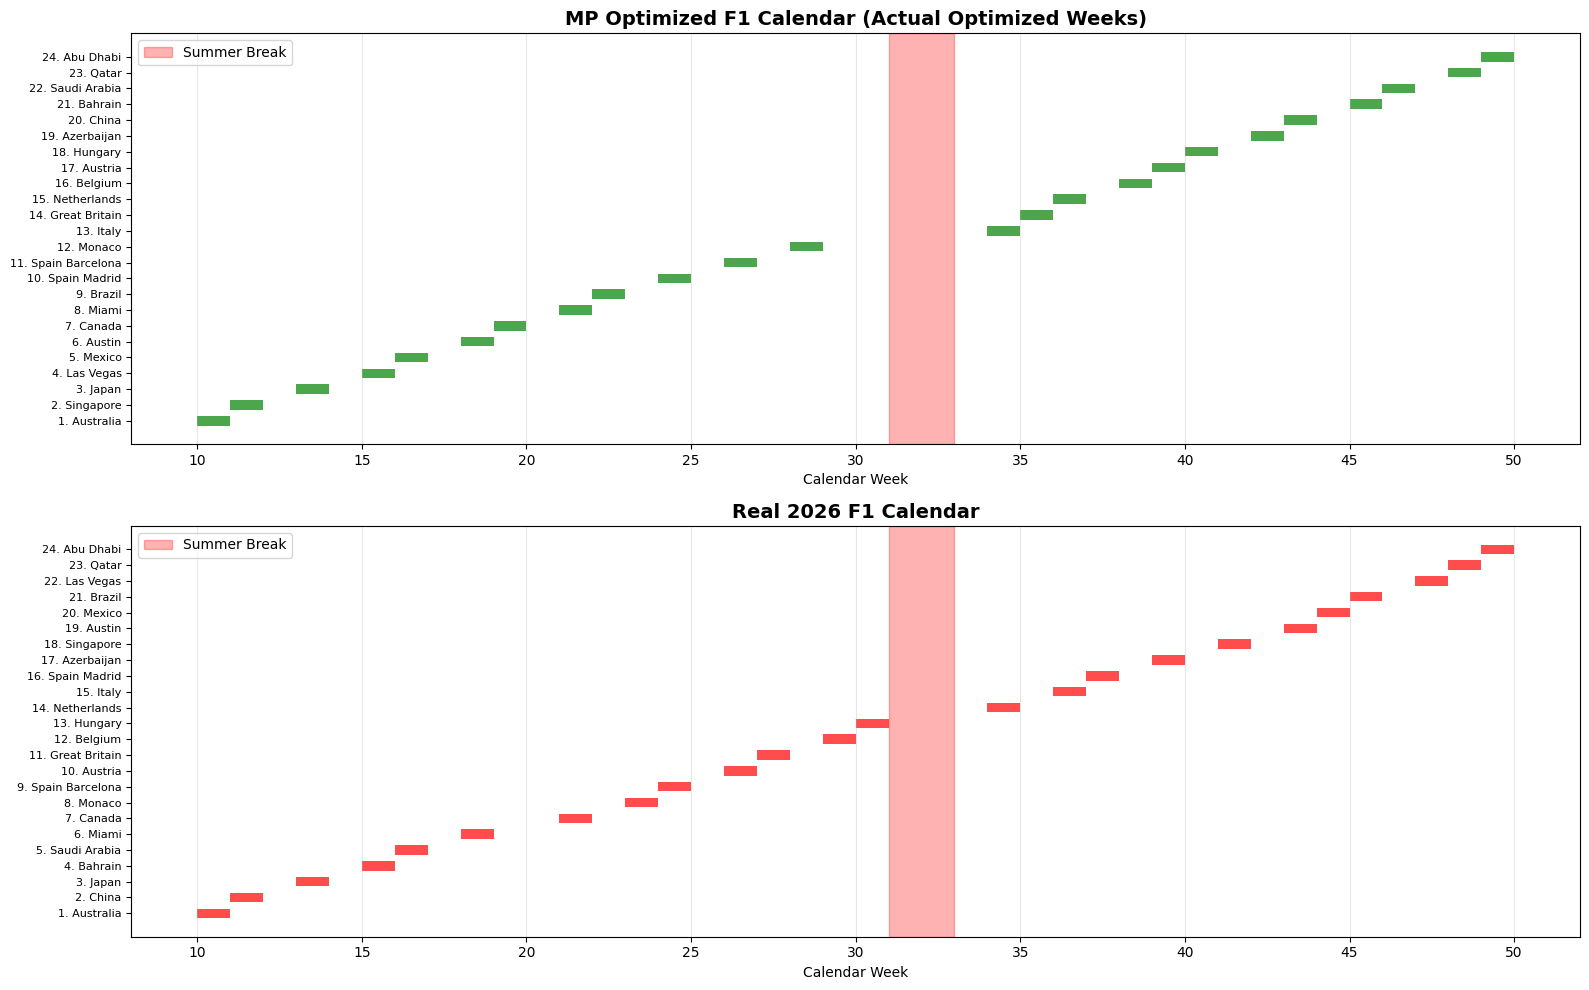


Creating interactive route maps...
Step 5: Performing detailed analysis...

DETAILED CALENDAR ANALYSIS WITH ACTUAL WEEKS
Pos | Optimized (Week)     | Real 2026 (Week)     | Week Δ | Dist Δ
----------------------------------------------------------------------
 1  | Australia    (W10) | Australia    (W10) |   --   | Start
 2  | Singapore    (W11) | China        (W11) |     = | ↑  2021
 3  | Japan        (W13) | Japan        (W13) |     = | ↓  3558
 4  | Las Vegas    (W15) | Bahrain      (W15) |     = | ↓  1131
 5  | Mexico       (W16) | Saudi Arabia (W16) |     = | ↓  1175
 6  | Austin       (W18) | Miami        (W18) |     = | ↑ 10404
 7  | Canada       (W19) | Canada       (W21) |    +2 | ↓   449
 8  | Miami        (W21) | Monaco       (W23) |    +2 | ↑  3868
 9  | Brazil       (W22) | Spain Barcelona (W24) |    +2 | ↓  6111
10  | Spain Madrid (W24) | Austria      (W26) |    +2 | ↓  7229
11  | Spain Barcelona (W26) | Great Britain (W27) |    +1 | ↑   738
12  | Monaco       (W28) | Be

In [13]:
# ========================================
# 8. EXECUTE THE DEMONSTRATION
# ========================================

# Execute the full demonstration
results = demonstrate_mp_optimization_fixed()

if results:
    print(f"\n SUCCESS! The MP model demonstrates how mathematical programming")
    print(f"   with logical constraints optimizes complex real-world problems!")

    print(f"\n KEY RESULTS:")
    print(
        f"   • Distance savings: {results['savings_km']:,.0f} km ({results['savings_percent']:.1f}%)"
    )
    print(f"   • MP logical constraints (<==> syntax) successfully applied")
    print(f"   • Complex scheduling constraints satisfied")
    print(f"   • Real-world validation completed")

    print(f"\n This demonstrates AMPL's MP capabilities for:")
    print(f"   ✓ Advanced logical constraint modeling")
    print(f"   ✓ Complex combinatorial optimization")
    print(f"   ✓ Real-world scheduling applications")
    print(f"   ✓ Geographic optimization problems")

In [14]:
# ========================================
# 9. DISPLAY INTERACTIVE VISUALIZATIONS
# ========================================

if results:
    # Display static comparison map
    # comparison_fig = create_dual_map_comparison(
    #    results['optimized_calendar'],
    #    REAL_2026_CALENDAR,
    #    CIRCUIT_COORDINATES,
    #    results['optimized_distance'],
    #    results['real_distance']
    # )
    # plt.show()

    # Display interactive maps
    display(HTML("<h3>🎯 MP Optimized Route (Green)</h3>"))
    display(results["opt_map"])

    print(f"\n🏁 MP MODEL DEMONSTRATION COMPLETE!")
    print("=" * 50)
    print(f"✅ Successfully used AMPL MP logical constraints (<==> syntax)")
    print(f"✅ Optimized complex scheduling with multiple constraint types")
    print(f"✅ Achieved {results['savings_percent']:.1f}% distance reduction")
    print(f"✅ Created comprehensive calendar and route visualizations")
    print(f"✅ Demonstrated real-world application of mathematical programming")


🏁 MP MODEL DEMONSTRATION COMPLETE!
✅ Successfully used AMPL MP logical constraints (<==> syntax)
✅ Optimized complex scheduling with multiple constraint types
✅ Achieved 37.0% distance reduction
✅ Created comprehensive calendar and route visualizations
✅ Demonstrated real-world application of mathematical programming


In [15]:
display(HTML("<h3>📅 Real 2026 F1 Calendar (Red)</h3>"))
display(results["real_map"])